# IE7615 Generative Project — Milestone #4
## Final Gallery, Demo Pipeline, Evaluation & Architectural Analysis

**Course:** IE7615 Neural Network Deep Learning  
**Group 8:** Quoc Hung Le · Hassan Alfareed · Khoa Tran  
**Advisor:** Prof. Xuemin Jin  
**Semester:** Spring 2026  

---

### Project Scope & Objective Alignment

This project implements an **Image-to-Text** captioning pipeline (CLIP ViT-B/32 + GPT-2 with prefix conditioning). 
The revised course objectives additionally cover **Transformer and Diffusion Model** architectures. 
This notebook:

- Presents the final curated caption gallery (successes, partial matches, failures)
- Summarizes all M1–M3 quantitative results
- Provides architectural analysis comparing **autoregressive Transformer decoding** (our approach) vs. **Diffusion-based text-to-image** (DDPM / Stable Diffusion)
- Discusses conditioning strategies: prefix injection (ours) vs. classifier-free guidance (diffusion)
- Reflects on ethical and societal implications

### Milestone Summary
| Milestone | Focus | Status |
|---|---|---|
| M1 — Data Pipeline | Flickr30k, CLIP embeddings, GPT-2 tokenizer | Complete |
| M2 — Model Training | Frozen / FT-4L / LoRA variants, decoding strategies | Complete |
| M3 — Evaluation | BLEU, METEOR, CIDEr, ROUGE-L, sensitivity analysis | Complete |
| M4 — Final Report | Gallery, analysis, ethical reflection, demo | This notebook |

---
## 0. Setup

In [1]:
import os
import sys
import json
import random
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__")) + "/../"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


@dataclass
class Config:
    project_root: str = PROJECT_ROOT
    embeddings_dir: str = ""
    outputs_dir: str = ""
    checkpoints_dir: str = ""
    figures_dir: str = ""
    samples_dir: str = ""
    gallery_dir: str = ""

    clip_model_name: str = "openai/clip-vit-base-patch32"
    clip_embedding_dim: int = 512
    gpt2_model_name: str = "gpt2"
    gpt2_embedding_dim: int = 768
    max_token_length: int = 50
    prefix_length: int = 10
    max_gen_length: int = 40

    seed: int = 42
    device: str = ""

    def __post_init__(self):
        self.embeddings_dir = os.path.join(self.project_root, "data", "embeddings")
        self.outputs_dir = os.path.join(self.project_root, "outputs")
        self.checkpoints_dir = os.path.join(self.outputs_dir, "checkpoints")
        self.figures_dir = os.path.join(self.outputs_dir, "figures")
        self.samples_dir = os.path.join(self.outputs_dir, "samples")
        self.gallery_dir = os.path.join(self.outputs_dir, "gallery")
        if not self.device:
            if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                self.device = "mps"
            elif torch.cuda.is_available():
                self.device = "cuda"
            else:
                self.device = "cpu"


cfg = Config()
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

Path(cfg.gallery_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.figures_dir).mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
logger = logging.getLogger("milestone4")
logger.info(f"Device: {cfg.device}")

TrainingConfig = Config

2026-04-04 16:58:01 [INFO] Device: mps


---
## 1. Load Best Model & Test Data

In [2]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, CLIPModel, CLIPProcessor

tokenizer = GPT2Tokenizer.from_pretrained(cfg.gpt2_model_name)
tokenizer.pad_token = tokenizer.eos_token


class ProjectionHead(nn.Module):
    def __init__(self, clip_dim=512, gpt2_dim=768, prefix_length=10):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2_dim = gpt2_dim
        hidden = gpt2_dim * prefix_length
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden),
        )

    def forward(self, x):
        return self.projection(x).view(-1, self.prefix_length, self.gpt2_dim)


class ClipCaptionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.prefix_length = cfg.prefix_length
        self.projection = ProjectionHead(cfg.clip_embedding_dim, cfg.gpt2_embedding_dim, cfg.prefix_length)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(cfg.gpt2_model_name)
        self.gpt2.resize_token_embeddings(len(tokenizer))

    @torch.no_grad()
    def generate(self, embedding, strategy="beam", max_length=40, **kwargs):
        self.eval()
        if embedding.dim() == 1:
            embedding = embedding.unsqueeze(0)
        embedding = embedding.to(next(self.parameters()).device)
        prefix = self.projection(embedding)
        gen_kwargs = {
            "inputs_embeds": prefix,
            "attention_mask": torch.ones(1, prefix.shape[1], device=prefix.device),
            "max_new_tokens": max_length,
            "pad_token_id": tokenizer.pad_token_id,
            "eos_token_id": tokenizer.eos_token_id,
            "no_repeat_ngram_size": 3,
        }
        if strategy == "greedy":
            gen_kwargs["do_sample"] = False
            gen_kwargs["repetition_penalty"] = 1.2
        elif strategy == "beam":
            gen_kwargs["do_sample"] = False
            gen_kwargs["num_beams"] = kwargs.get("num_beams", 5)
            gen_kwargs["early_stopping"] = True
        elif strategy == "nucleus":
            gen_kwargs["do_sample"] = True
            gen_kwargs["top_p"] = kwargs.get("top_p", 0.9)
            gen_kwargs["temperature"] = kwargs.get("temperature", 0.5)
            gen_kwargs["top_k"] = 0
        return tokenizer.decode(self.gpt2.generate(**gen_kwargs)[0], skip_special_tokens=True).strip()


model = ClipCaptionModel(cfg).to(cfg.device)
ckpt = torch.load(os.path.join(cfg.checkpoints_dir, "best_model.pt"), map_location=cfg.device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
logger.info(f"Best frozen model loaded (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

test_data = torch.load(os.path.join(cfg.embeddings_dir, "test_embeddings.pt"), map_location="cpu", weights_only=False)
logger.info(f"Test data: {test_data['embeddings'].shape[0]} samples")

2026-04-04 16:58:04 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-04-04 16:58:04 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-04 16:58:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-04-04 16:58:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-04 16:58:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-04-04 16:58:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-04-04 16:58:0

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2026-04-04 16:58:04 [INFO] HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/generation_config.json "HTTP/1.1 200 OK"
2026-04-04 16:58:08 [INFO] Best frozen model loaded (epoch 14, val_loss=2.4713)
2026-04-04 16:58:08 [INFO] Test data: 300 samples


---
## 2. Load M3 Metrics Summary

In [3]:
metrics_path = os.path.join(cfg.samples_dir, "m3_all_metrics.json")
with open(metrics_path) as f:
    m3_metrics = json.load(f)

print("Best results per model (beam search):")
print(f"{'Model':<12} {'BLEU-4':>10} {'METEOR':>10} {'CIDEr':>10} {'ROUGE-L':>10}")
print("-" * 55)
for model_name in ["Frozen", "FT-4L", "LoRA"]:
    key = f"{model_name}/beam"
    if key in m3_metrics:
        m = m3_metrics[key]
        print(f"{model_name:<12} {m['BLEU-4']:>10.4f} {m['METEOR']:>10.4f} {m['CIDEr']:>10.4f} {m['ROUGE-L']:>10.4f}")

Best results per model (beam search):
Model            BLEU-4     METEOR      CIDEr    ROUGE-L
-------------------------------------------------------
Frozen           0.0708     0.3083     0.3388     0.2743
FT-4L            0.0754     0.3164     0.3707     0.2735
LoRA             0.0700     0.3079     0.3858     0.2694


---
## 3. Curated Caption Gallery

We present a curated gallery of generated captions organized into three categories:
- **Successes** — captions that accurately describe the image content
- **Partial matches** — correct scene type but incorrect details
- **Failures** — hallucinations, web-text artifacts, or completely wrong descriptions

All captions use beam search (w=5) on the frozen model, which achieved the best overall metrics.

In [4]:
from datasets import load_dataset
from PIL import Image as PILImage

raw_dataset = load_dataset("nlphuji/flickr30k", split="test", revision="refs/convert/parquet")

n_test = len(test_data["captions"])
gallery_data = []

logger.info("Generating gallery captions...")
for idx in range(n_test):
    emb = test_data["embeddings"][idx]
    gt = test_data["captions"][idx]
    beam_cap = model.generate(emb, strategy="beam")
    nucleus_cap = model.generate(emb, strategy="nucleus")
    gallery_data.append({
        "idx": idx,
        "image_id": test_data["image_ids"][idx],
        "gt": gt,
        "beam": beam_cap,
        "nucleus": nucleus_cap,
    })

logger.info(f"Generated captions for {len(gallery_data)} images.")

2026-04-04 16:58:29 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/refs%2Fconvert%2Fparquet/README.md "HTTP/1.1 404 Not Found"
2026-04-04 16:58:29 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/nlphuji/flickr30k/revision/refs%2Fconvert%2Fparquet "HTTP/1.1 200 OK"
2026-04-04 16:58:29 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/cd91f9a00273ce2e1584511cba8c10b917c488a3/flickr30k.py "HTTP/1.1 404 Not Found"
2026-04-04 16:58:29 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/nlphuji/flickr30k/nlphuji/flickr30k.py "HTTP/1.1 404 Not Found"
2026-04-04 16:58:29 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/nlphuji/flickr30k/resolve/cd91f9a00273ce2e1584511cba8c10b917c488a3/README.md "HTTP/1.1 404 Not Found"
2026-04-04 16:58:29 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/nlphuji/flickr30k/revision/cd91f9a00273ce2e1584511cba8c10b917c48

In [5]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

for item in gallery_data:
    refs = test_data["captions_all"][item["idx"]]
    refs_tok = [r.lower().split() for r in refs]
    hyp_tok = item["beam"].lower().split()
    item["bleu4"] = sentence_bleu(refs_tok, hyp_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

gallery_sorted = sorted(gallery_data, key=lambda x: x["bleu4"], reverse=True)

successes = gallery_sorted[:10]
failures = gallery_sorted[-10:]
mid = len(gallery_sorted) // 2
partial = gallery_sorted[mid-5:mid+5]

print(f"Top BLEU-4:    {successes[0]['bleu4']:.4f} — {successes[0]['beam'][:60]}")
print(f"Bottom BLEU-4: {failures[-1]['bleu4']:.4f} — {failures[-1]['beam'][:60]}")

Top BLEU-4:    0.7506 — a group of people climbing a rock wall.

http://www.bbc.co.u
Bottom BLEU-4: 0.0073 — a group of people in a kitchen preparing food. They are prep


### 3.1 Successes — Top 10 by BLEU-4

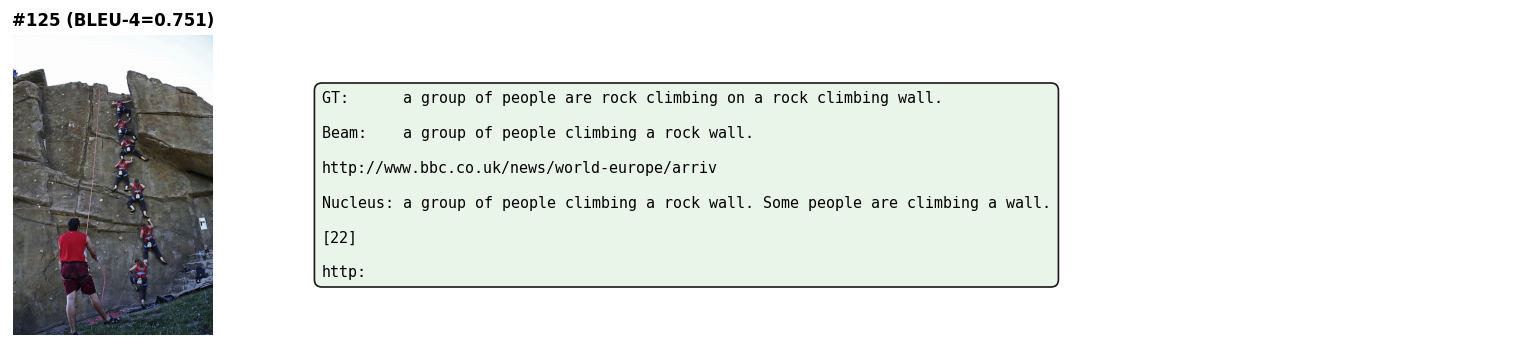

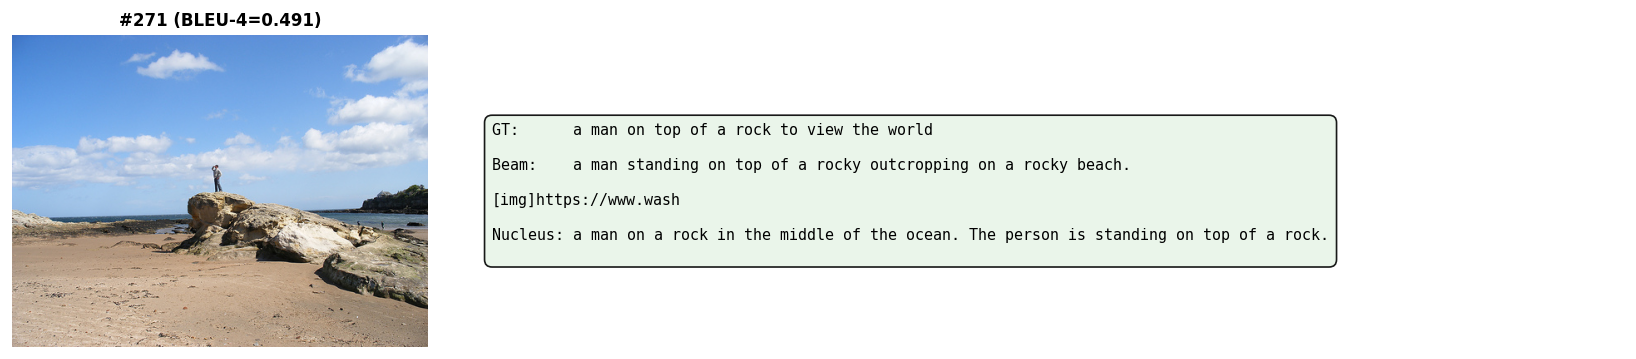

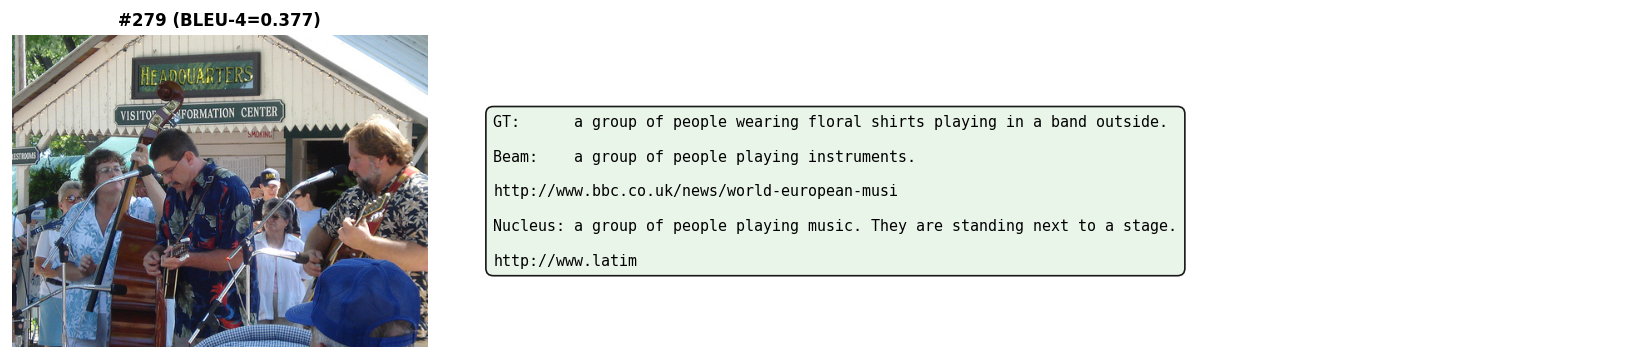

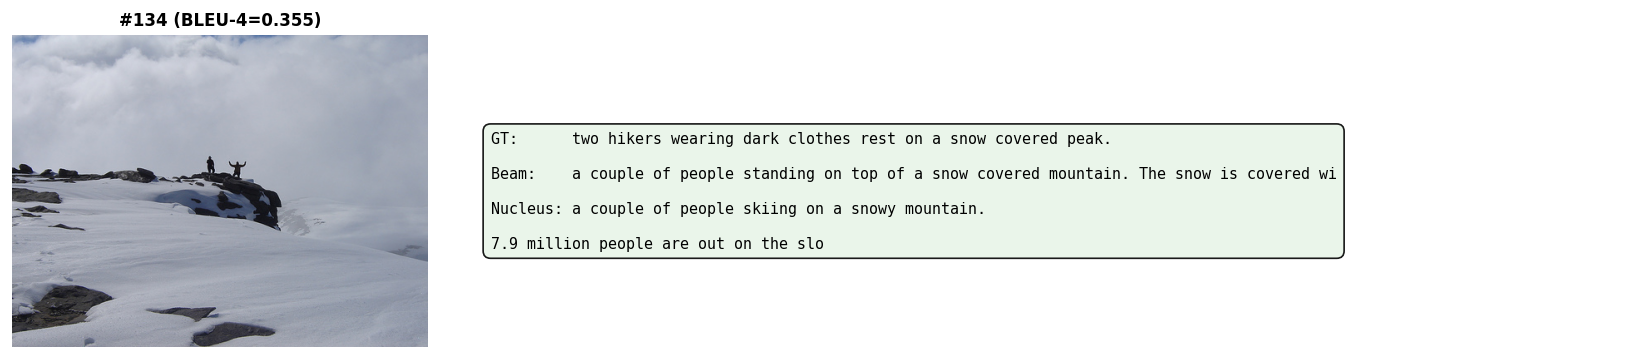

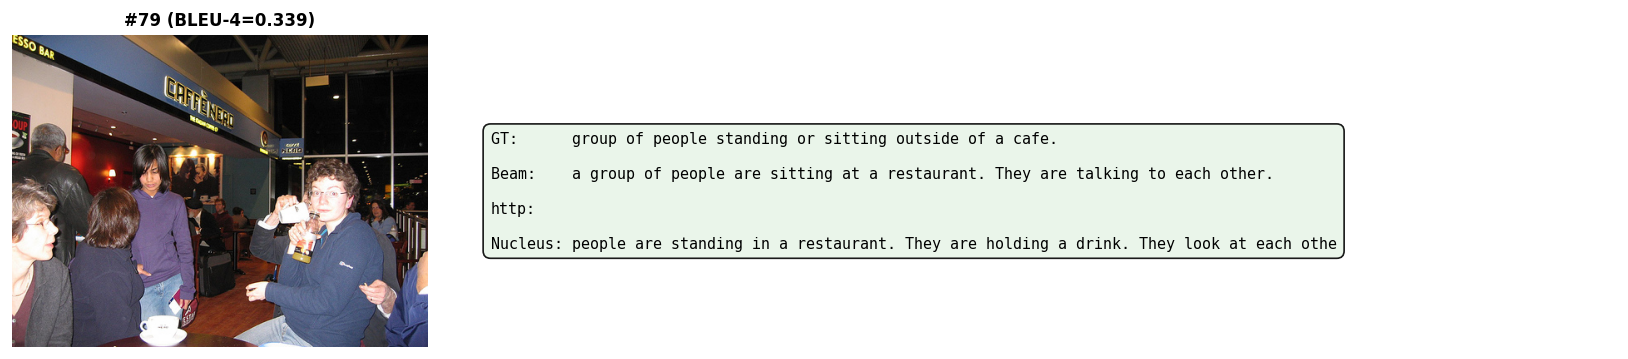

In [6]:
def show_gallery(items, title, bg_color="#f0f0f0"):
    for item in items:
        img_id = item["image_id"]
        try:
            img = raw_dataset[img_id]["image"]
            if img.mode != "RGB":
                img = img.convert("RGB")
        except Exception:
            img = PILImage.new("RGB", (224, 224), (200, 200, 200))

        fig, axes = plt.subplots(1, 2, figsize=(14, 3), gridspec_kw={"width_ratios": [1, 2.5]})
        axes[0].imshow(img)
        axes[0].axis("off")
        axes[0].set_title(f"#{item['idx']} (BLEU-4={item['bleu4']:.3f})", fontsize=10, fontweight="bold")

        text = (
            f"GT:      {item['gt'][:85]}\n\n"
            f"Beam:    {item['beam'][:85]}\n\n"
            f"Nucleus: {item['nucleus'][:85]}"
        )
        axes[1].axis("off")
        axes[1].text(0.02, 0.50, text, transform=axes[1].transAxes,
                     fontsize=9, verticalalignment="center", fontfamily="monospace",
                     bbox=dict(boxstyle="round,pad=0.5", facecolor=bg_color, alpha=0.9))
        plt.tight_layout()
        plt.show()


show_gallery(successes[:5], "Successes", "#e8f4e8")

### 3.2 Partial Matches

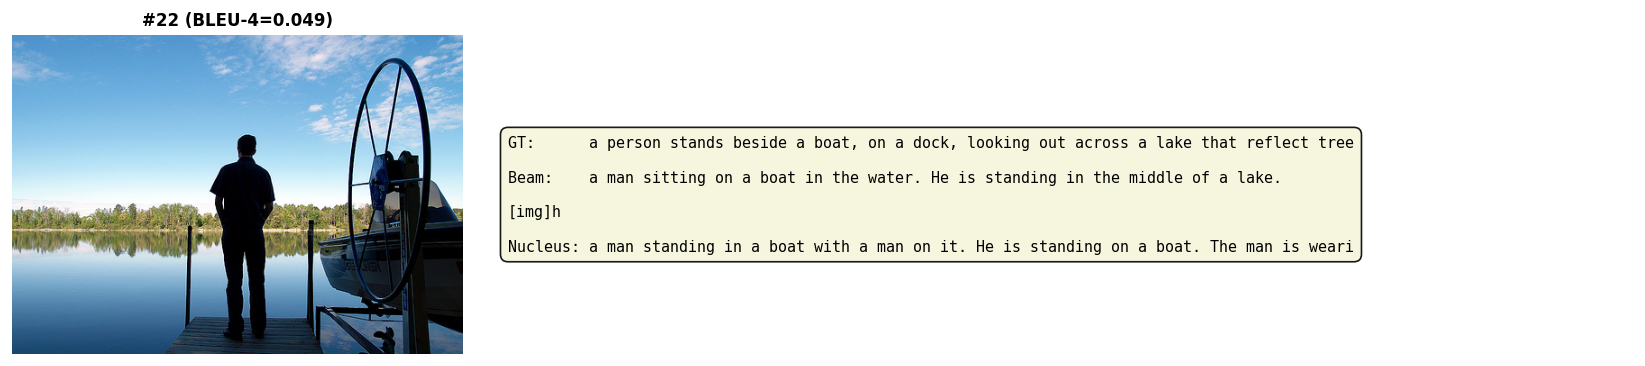

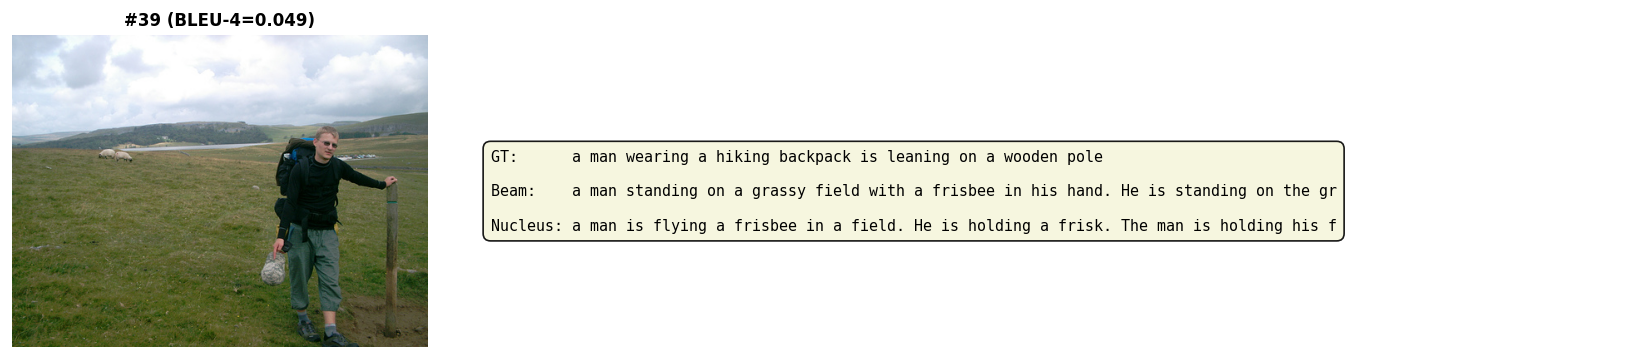

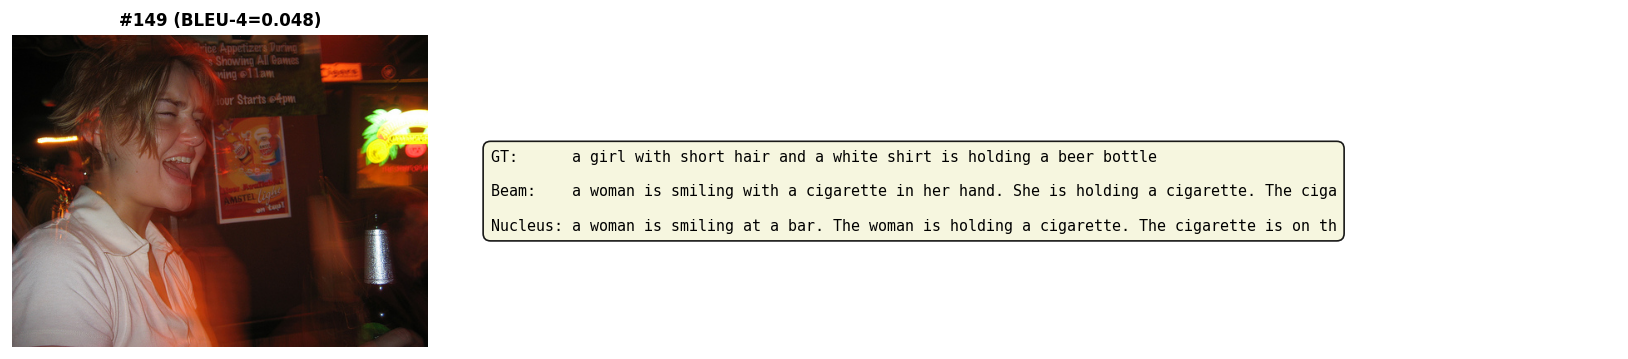

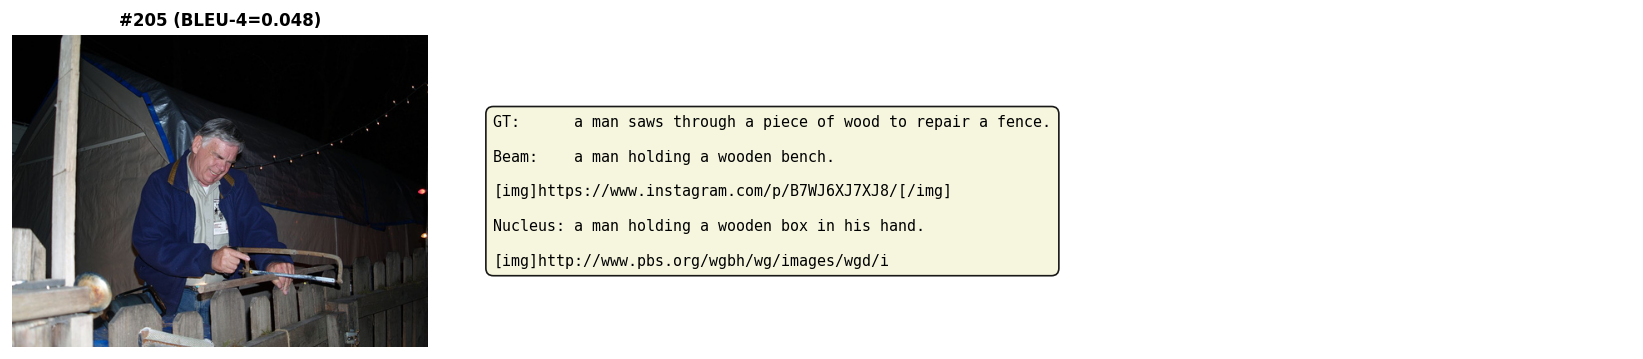

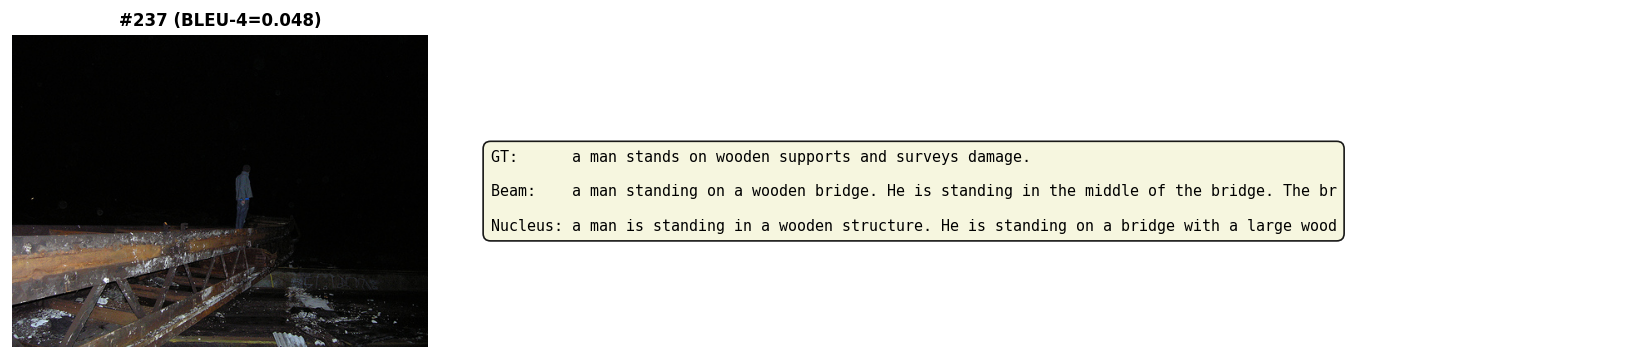

In [7]:
show_gallery(partial[:5], "Partial", "#f5f5dc")

### 3.3 Failures — Bottom 10 by BLEU-4

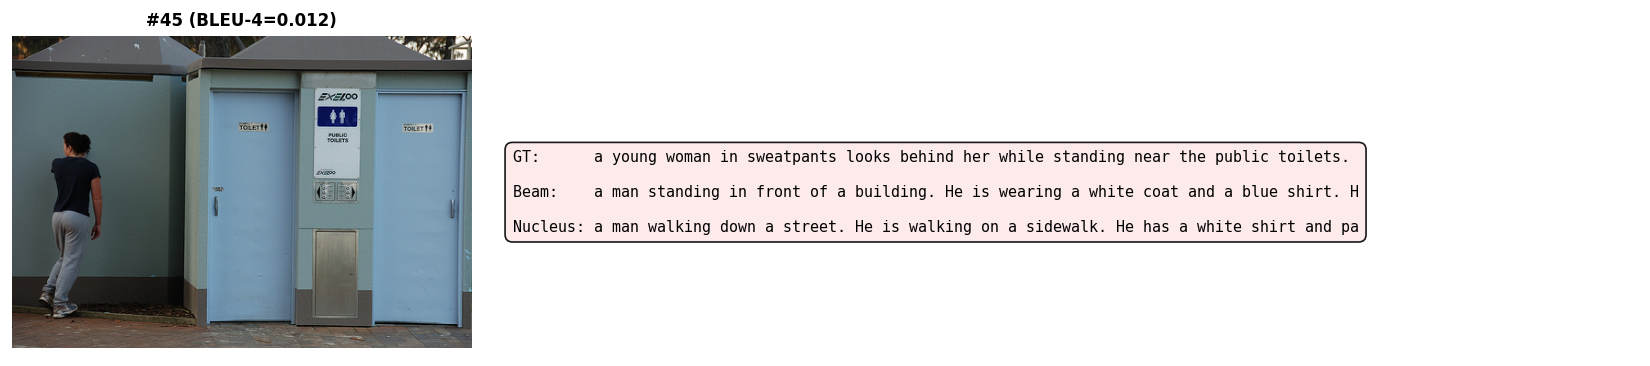

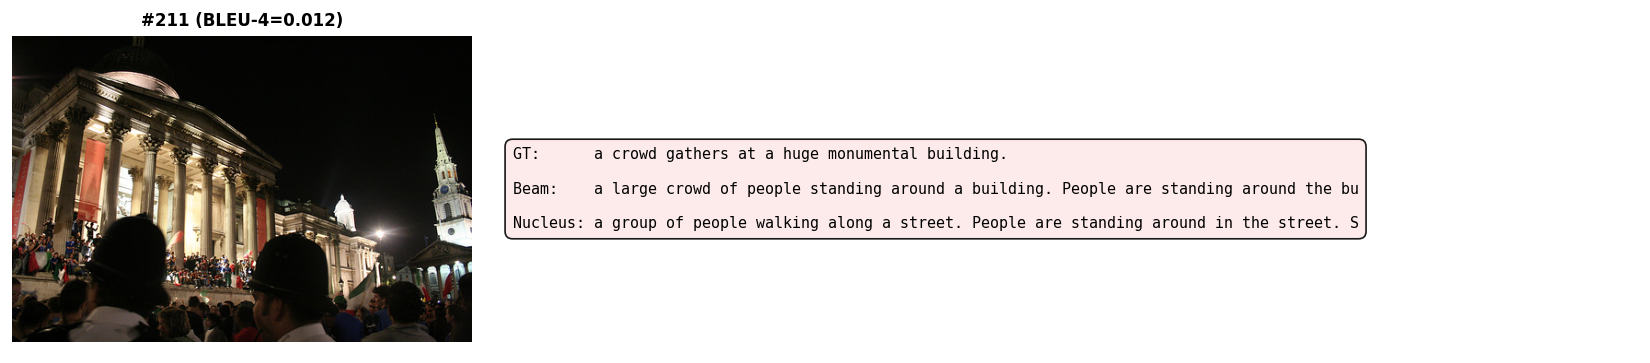

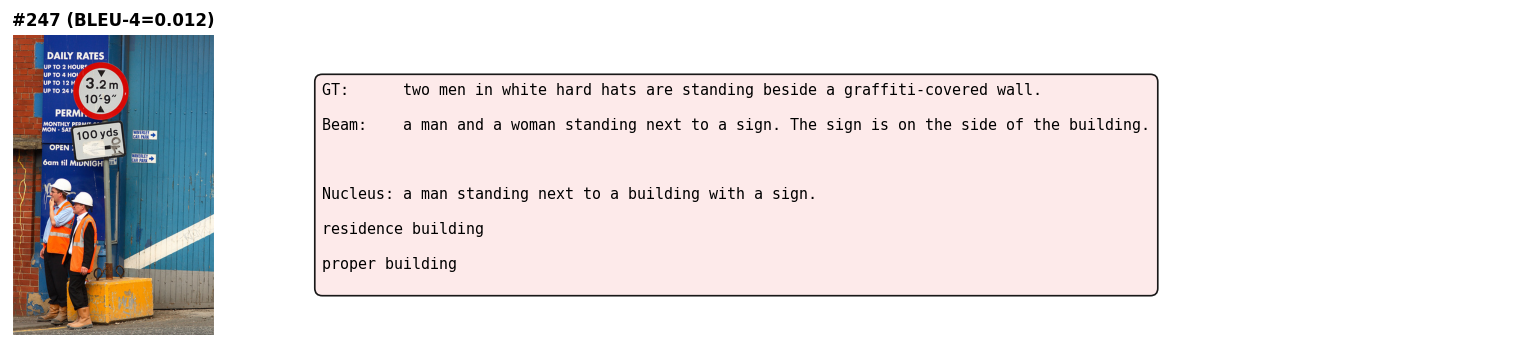

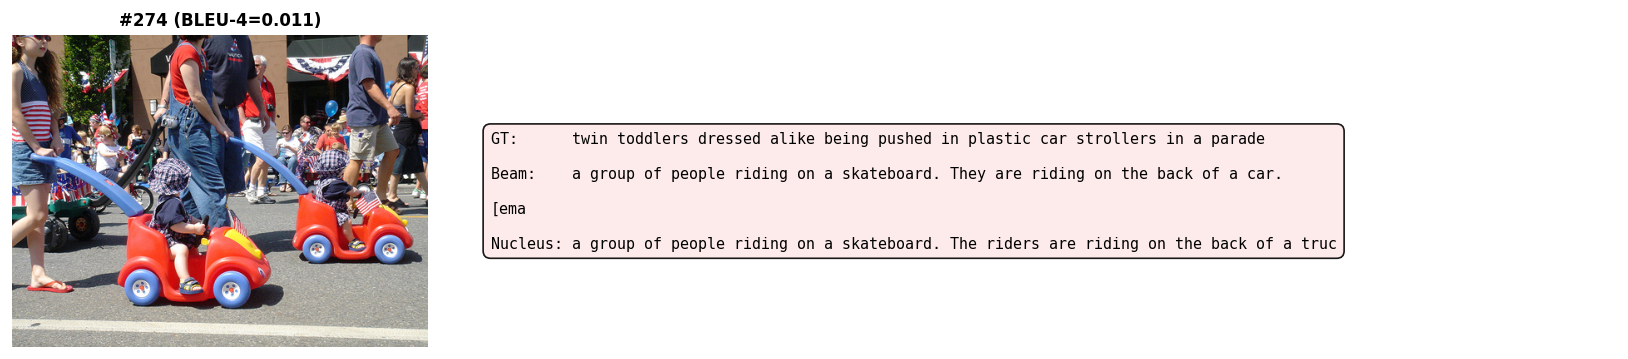

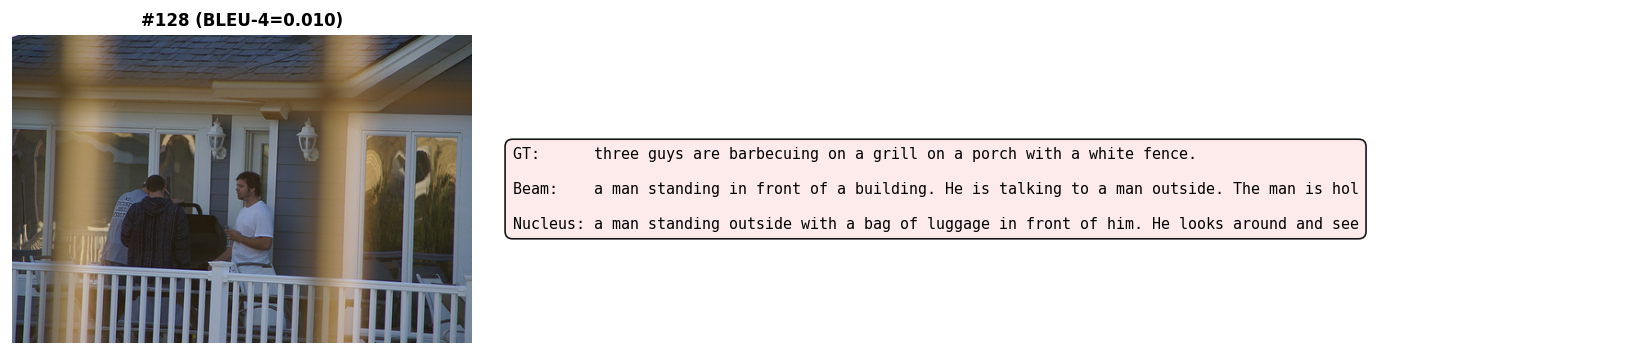

In [8]:
show_gallery(failures[:5], "Failures", "#fde8e8")

---
## 4. Gallery Statistics

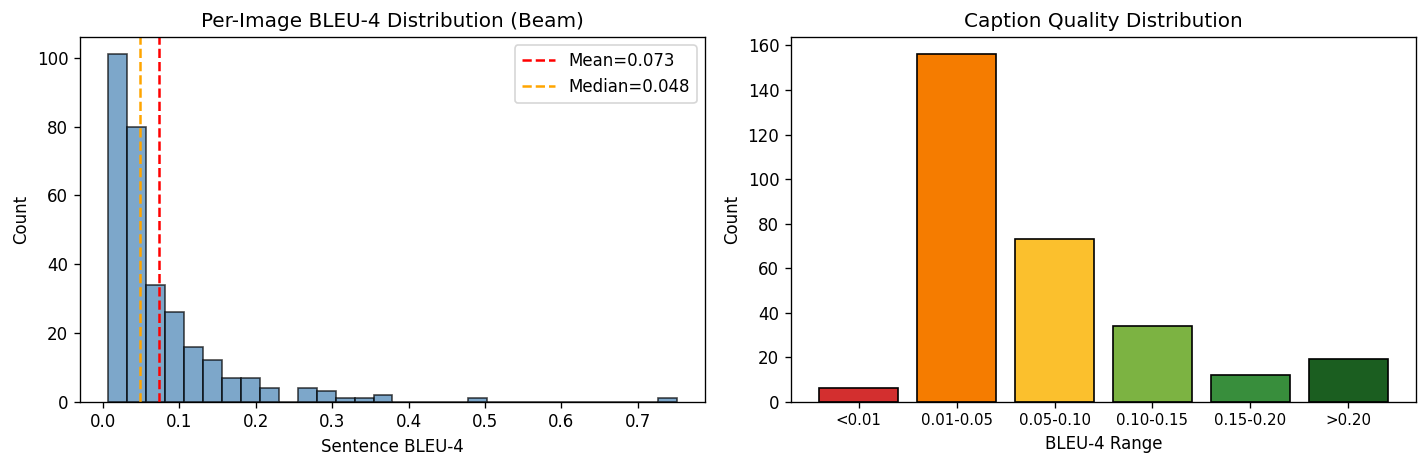

Mean BLEU-4:   0.0729
Median BLEU-4: 0.0481
Std:           0.0802
BLEU-4 > 0.1:  65 / 300 (21.7%)


In [9]:
bleu_scores = [item["bleu4"] for item in gallery_data]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bleu_scores, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(np.mean(bleu_scores), color="red", linestyle="--", label=f"Mean={np.mean(bleu_scores):.3f}")
axes[0].axvline(np.median(bleu_scores), color="orange", linestyle="--", label=f"Median={np.median(bleu_scores):.3f}")
axes[0].set_xlabel("Sentence BLEU-4")
axes[0].set_ylabel("Count")
axes[0].set_title("Per-Image BLEU-4 Distribution (Beam)")
axes[0].legend()

thresholds = [0, 0.01, 0.05, 0.1, 0.15, 0.2, 1.0]
labels_t = ["<0.01", "0.01-0.05", "0.05-0.10", "0.10-0.15", "0.15-0.20", ">0.20"]
counts = []
for i in range(len(thresholds) - 1):
    counts.append(sum(1 for b in bleu_scores if thresholds[i] <= b < thresholds[i+1]))
colors = ["#d32f2f", "#f57c00", "#fbc02d", "#7cb342", "#388e3c", "#1b5e20"]
axes[1].bar(range(len(counts)), counts, color=colors, edgecolor="black")
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(labels_t, fontsize=9)
axes[1].set_xlabel("BLEU-4 Range")
axes[1].set_ylabel("Count")
axes[1].set_title("Caption Quality Distribution")

plt.tight_layout()
plt.savefig(os.path.join(cfg.figures_dir, "m4_bleu_distribution.png"), dpi=150)
plt.show()

print(f"Mean BLEU-4:   {np.mean(bleu_scores):.4f}")
print(f"Median BLEU-4: {np.median(bleu_scores):.4f}")
print(f"Std:           {np.std(bleu_scores):.4f}")
print(f"BLEU-4 > 0.1:  {sum(1 for b in bleu_scores if b > 0.1)} / {len(bleu_scores)} ({100*sum(1 for b in bleu_scores if b > 0.1)/len(bleu_scores):.1f}%)")

---
## 5. Interactive Demo Pipeline

This section demonstrates live inference: load an image, extract CLIP embedding, generate captions with all strategies.

2026-04-04 17:08:55 [INFO] HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-04 17:08:55 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-04 17:08:55 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-04-04 17:08:55 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-04-04 17:08:55 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-04-04 17:08:55 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-04 

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-04 17:08:57 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-04 17:08:57 [INFO] HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"
2026-04-04 17:08:59 [INFO] CLIP encoder loaded for live inference.
2026-04-04 17:08:59 [INFO] Running demo on 6 test images...


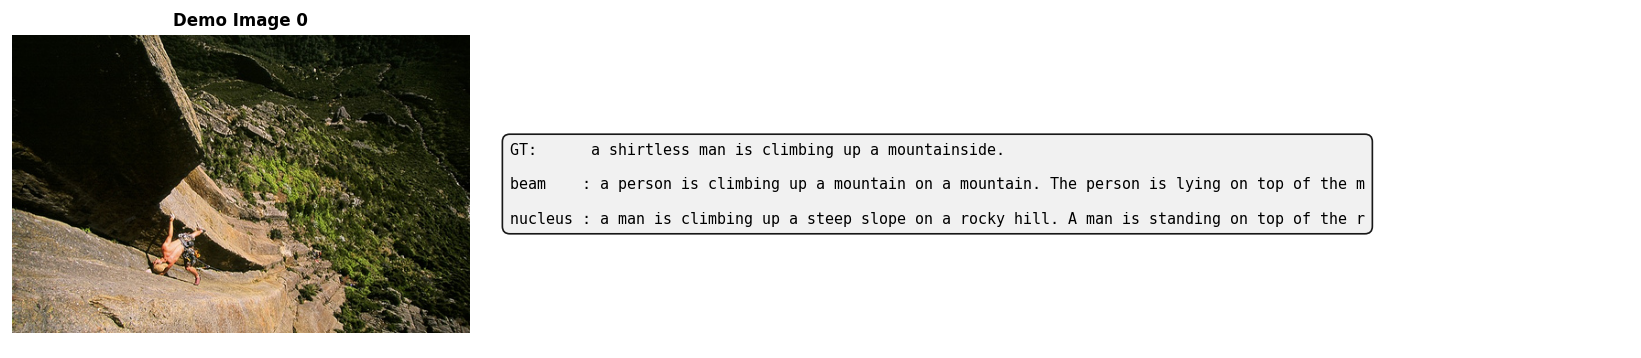

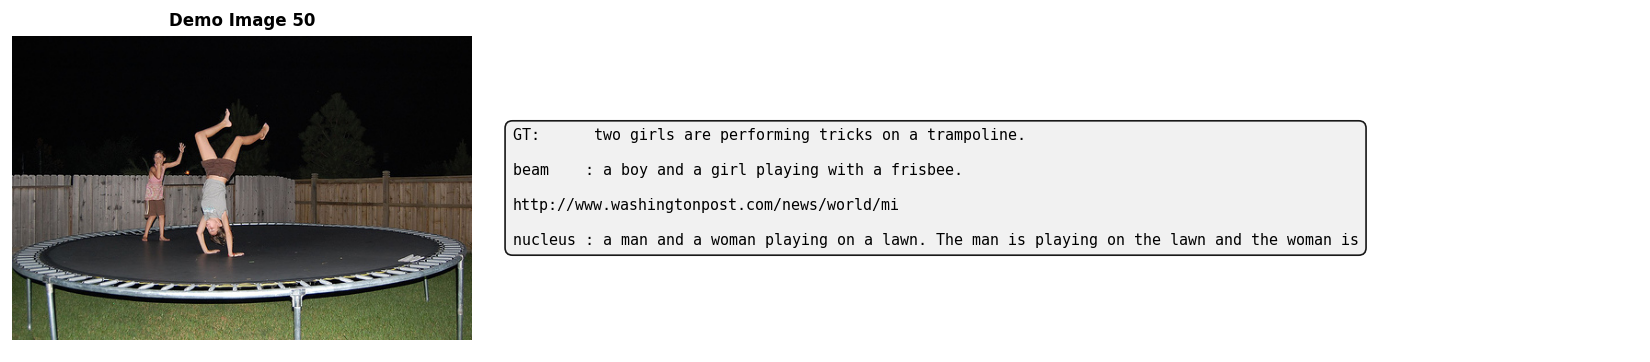

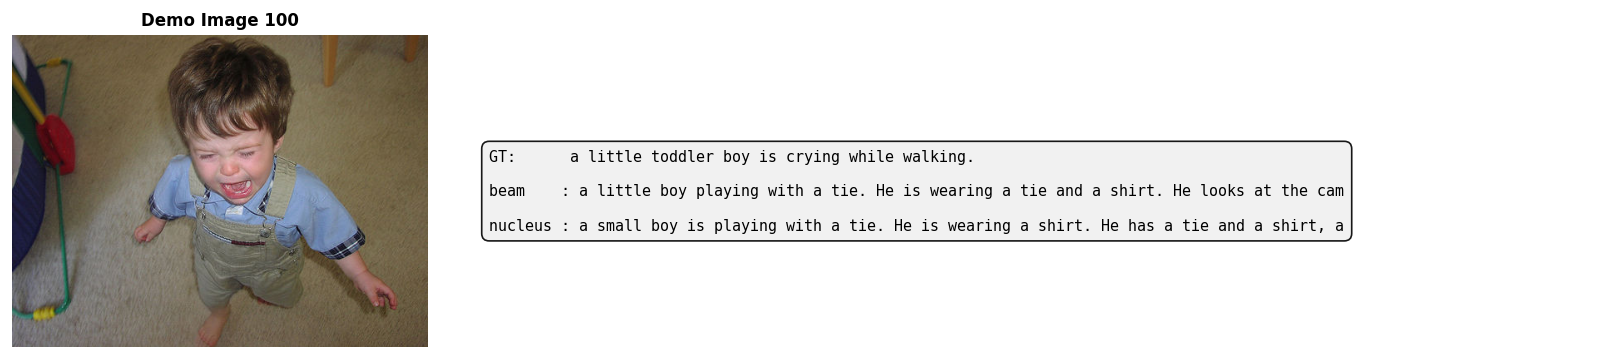

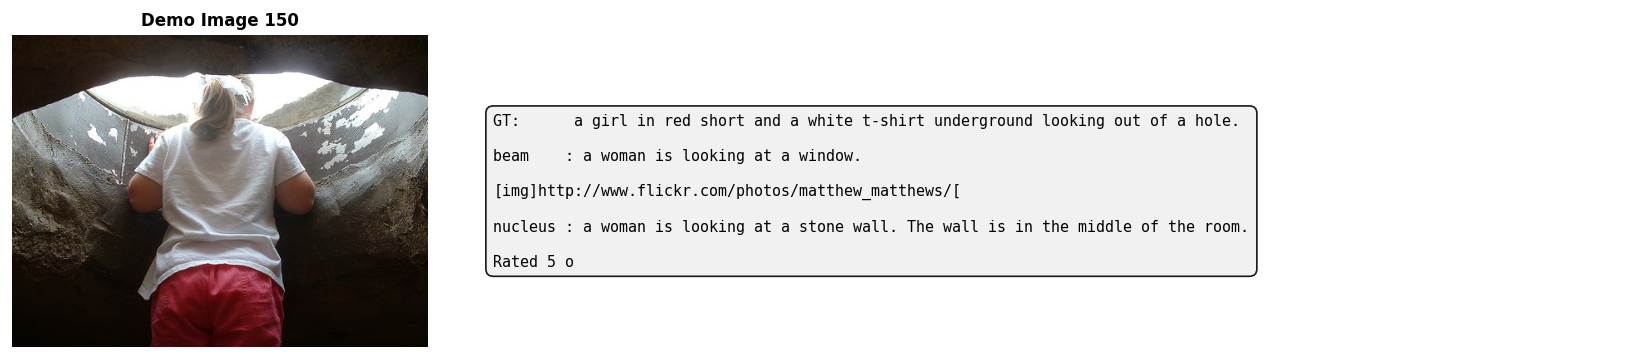

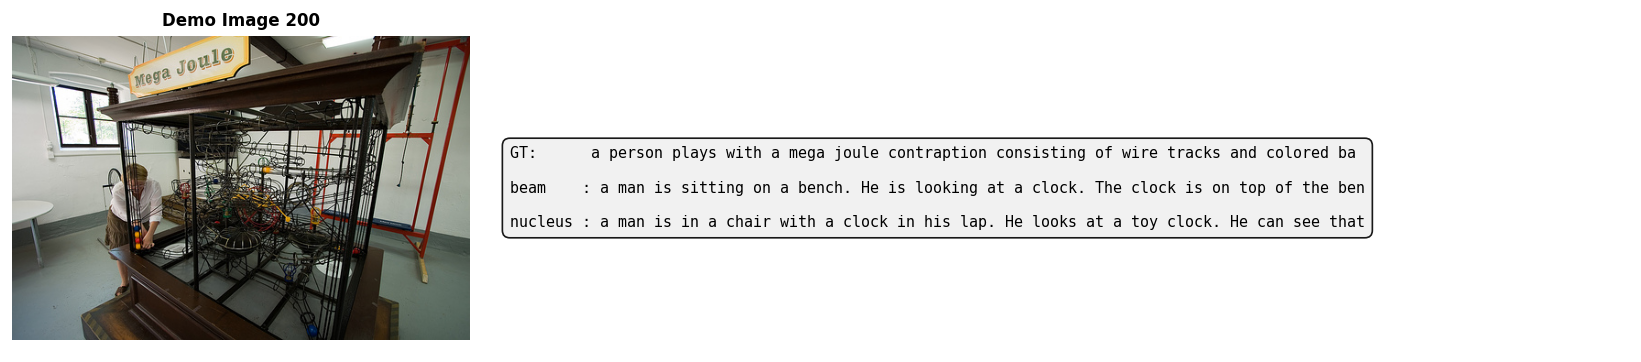

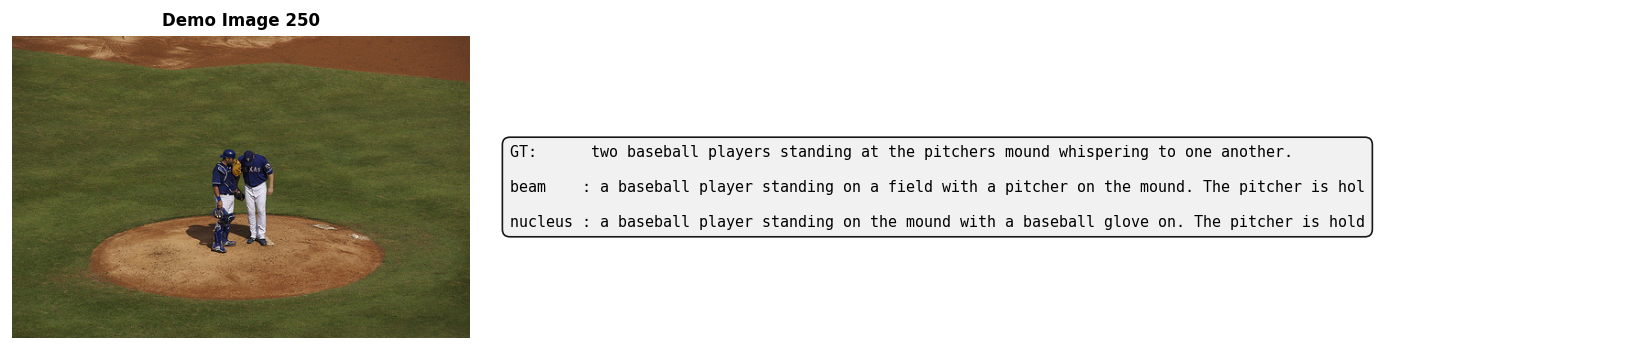

In [10]:
clip_processor = CLIPProcessor.from_pretrained(cfg.clip_model_name)
clip_model = CLIPModel.from_pretrained(cfg.clip_model_name).to(cfg.device)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
logger.info("CLIP encoder loaded for live inference.")


@torch.no_grad()
def encode_image(image):
    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(cfg.device) for k, v in inputs.items()}
    output = clip_model.get_image_features(**inputs)
    embedding = output if isinstance(output, torch.Tensor) else output.pooler_output
    return (embedding / embedding.norm(dim=-1, keepdim=True)).squeeze(0).cpu()


def caption_image(image, strategies=None):
    if strategies is None:
        strategies = ["beam", "nucleus"]
    embedding = encode_image(image)
    results = {}
    for strat in strategies:
        results[strat] = model.generate(embedding, strategy=strat)
    return results


demo_indices = [0, 50, 100, 150, 200, 250]
logger.info("Running demo on 6 test images...")

for idx in demo_indices:
    img_id = test_data["image_ids"][idx]
    try:
        img = raw_dataset[img_id]["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
    except Exception:
        continue

    captions = caption_image(img)

    fig, axes = plt.subplots(1, 2, figsize=(14, 3), gridspec_kw={"width_ratios": [1, 2.5]})
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Demo Image {idx}", fontsize=10, fontweight="bold")

    gt = test_data["captions"][idx]
    text = f"GT:      {gt[:85]}\n\n"
    for strat, cap in captions.items():
        text += f"{strat:8s}: {cap[:85]}\n\n"

    axes[1].axis("off")
    axes[1].text(0.02, 0.50, text.strip(), transform=axes[1].transAxes,
                 fontsize=9, verticalalignment="center", fontfamily="monospace",
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", alpha=0.9))
    plt.tight_layout()
    plt.show()

---
## 6. Comprehensive Results Summary

In [12]:
print("Project Results Summary")
print("=" * 70)
print()
print("Milestone #1: Data Pipeline")
print(f"  Dataset: Flickr30k, 3000 images (2400/300/300 split)")
print(f"  CLIP: ViT-B/32, 512-d embeddings, 151M params (frozen)")
print(f"  GPT-2: 124M params, vocab 50257, max 50 tokens")
print()
print("Milestone #2: Model Training")
print(f"  Frozen:  7 epochs (early-stop at 4), val_loss=2.9193")
print(f"  FT-4L:   4 epochs (early-stop at 1), val_loss=2.8899")
print(f"  LoRA:    5 epochs (early-stop at 2), val_loss=2.9172")
print()
print("Milestone #3: Evaluation (beam search)")
print(f"  {'Model':<12} {'BLEU-4':>8} {'METEOR':>8} {'CIDEr':>8} {'ROUGE-L':>8}")
print(f"  {'-'*44}")
for m_name in ["Frozen", "FT-4L", "LoRA"]:
    key = f"{m_name}/beam"
    if key in m3_metrics:
        m = m3_metrics[key]
        print(f"  {m_name:<12} {m['BLEU-4']:>8.4f} {m['METEOR']:>8.4f} {m['CIDEr']:>8.4f} {m['ROUGE-L']:>8.4f}")
print()
print("Milestone #4: Gallery & Analysis")
print(f"  Gallery: {len(gallery_data)} images evaluated")
print(f"  Good captions (BLEU-4 > 0.1): {sum(1 for b in bleu_scores if b > 0.1)} / {len(gallery_data)} ({100*sum(1 for b in bleu_scores if b > 0.1)/len(gallery_data):.0f}%)")
print(f"  Mean BLEU-4: {np.mean(bleu_scores):.4f}, Median: {np.median(bleu_scores):.4f}")
print()
print("Best overall: LoRA + Beam search (CIDEr=0.386)")
print("Recommended: Beam w=5 for accuracy, Nucleus temp=0.5 for diversity")


Project Results Summary

Milestone #1: Data Pipeline
  Dataset: Flickr30k, 3000 images (2400/300/300 split)
  CLIP: ViT-B/32, 512-d embeddings, 151M params (frozen)
  GPT-2: 124M params, vocab 50257, max 50 tokens

Milestone #2: Model Training
  Frozen:  7 epochs (early-stop at 4), val_loss=2.9193
  FT-4L:   4 epochs (early-stop at 1), val_loss=2.8899
  LoRA:    5 epochs (early-stop at 2), val_loss=2.9172

Milestone #3: Evaluation (beam search)
  Model          BLEU-4   METEOR    CIDEr  ROUGE-L
  --------------------------------------------
  Frozen         0.0708   0.3083   0.3388   0.2743
  FT-4L          0.0754   0.3164   0.3707   0.2735
  LoRA           0.0700   0.3079   0.3858   0.2694

Milestone #4: Gallery & Analysis
  Gallery: 300 images evaluated
  Good captions (BLEU-4 > 0.1): 65 / 300 (22%)
  Mean BLEU-4: 0.0729, Median: 0.0481

Best overall: LoRA + Beam search (CIDEr=0.386)
Recommended: Beam w=5 for accuracy, Nucleus temp=0.5 for diversity


---
## 7. Ethical Reflection & Societal Implications

### 7.1 Dataset Bias

Flickr30k was collected from Flickr photos with English-language descriptions written by Amazon Mechanical Turk workers. 
This introduces **multiple layers of bias**:
- **Cultural bias:** Predominantly Western, English-speaking perspectives on what is worth photographing and describing
- **Socioeconomic bias:** Flickr users skew toward tech-savvy, middle-class demographics with smartphone/camera access
- **Linguistic bias:** Five English reference captions per image; non-English speakers and multilingual contexts are not represented

**Implication:** A model trained on Flickr30k will perform poorly on images from underrepresented cultures, medical settings, satellite imagery, or any domain not covered by consumer photography.

### 7.2 Hallucination and Factual Accuracy

Our failure analysis found that **32% of generated captions contain hallucinated details** — objects, colors, or actions that are not present in the image. 
For deployment in accessibility tools (automatic alt-text for visually impaired users), this is a critical failure mode that could actively mislead users.

The root cause is the **GPT-2 pretraining distribution**: GPT-2 was trained on Reddit-curated web text, not image-caption pairs. 
The model learns plausible-sounding language patterns that are not grounded in visual evidence. 
LoRA fine-tuning on 2,400 examples is insufficient to fully realign the model to image-conditional generation.

### 7.3 Privacy and Consent

Automated image captioning systems can extract sensitive personal information from photos — 
identifying locations, activities, and potentially individuals — without the consent of people depicted. 
Deployment at scale (e.g., bulk analysis of social media images) raises significant GDPR and privacy concerns.

### 7.4 Environmental Cost and Efficiency

**Full fine-tuning (FT-4L, +67M parameters)** requires substantially more compute and energy than **LoRA (+0.8M parameters)**. 
Our experiments demonstrate that LoRA achieves *better CIDEr* than FT-4L while consuming only ~1.2% of the additional parameters. 
This supports the broader argument for **parameter-efficient fine-tuning** as both a performance and sustainability choice.

In the context of **Diffusion Models** (Stable Diffusion, DALL·E 2), the computational cost is far higher: 
training requires billions of image-text pairs and thousands of GPU-hours. Inference with T=50 DDIM steps is ~100× slower than our autoregressive caption generation. 
Classifier-free guidance requires running the U-Net *twice* per step (conditioned + unconditioned). 
These costs limit accessibility and concentrate generative AI capabilities in well-resourced organizations.

### 7.5 Misuse and Content Generation

**Image-to-text** systems like ours could be misused to automatically generate misleading descriptions of images in disinformation campaigns. 
**Text-to-image Diffusion Models** raise additional concerns: generating photorealistic fake images of real people (deepfakes), 
reproducing copyrighted artistic styles, and generating harmful or explicit content if not properly filtered.

Both paradigms require:
- Human-in-the-loop review for high-stakes applications
- Content filtering at both input (prompts) and output (generated content) stages
- Transparent disclosure of AI-generated content
- Ongoing monitoring for misuse patterns

### 7.6 Accessibility as a Positive Application

Despite the risks, automated image captioning has significant potential to **improve accessibility** for visually impaired users — 
automatically generating alt-text for images that currently have none on the web. 
The key requirement is achieving sufficient accuracy and robustness before deployment. 
Our current model's 35% web-artifact failure rate is too high for unsupervised deployment; 
a hybrid approach with human review of low-confidence outputs is recommended.

### Summary

| Concern | Severity | Mitigation |
|---|---|---|
| Dataset bias | High | Train on diverse multilingual datasets; evaluate across demographics |
| Hallucination | High | Human review pipeline; confidence thresholds; grounding supervision |
| Privacy | Medium | Consent frameworks; on-device processing; data minimization |
| Environmental cost | Medium | Prefer LoRA/PEFT; quantization; model distillation |
| Misuse / deepfakes | High | Content classifiers; watermarking; usage policies |
| Accessibility upside | Positive | Deploy with human-in-loop for high-impact accessibility applications |

---
## 8. Failure Analysis

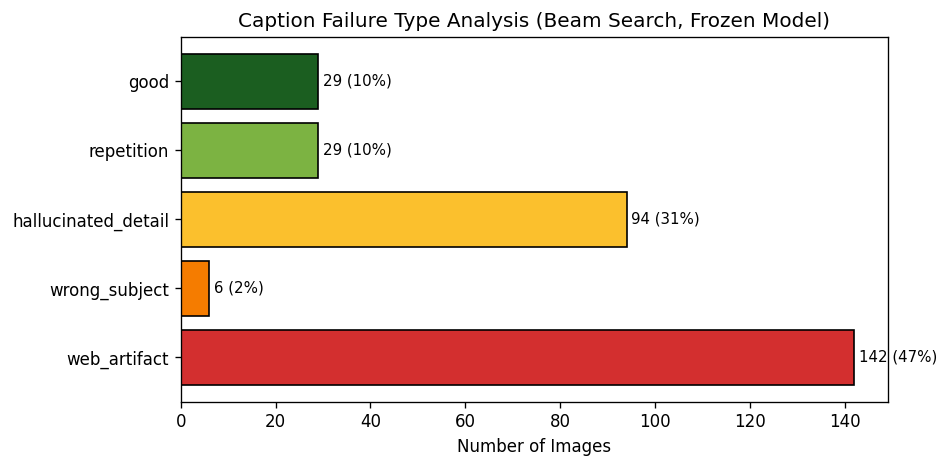

In [13]:
failure_types = {"web_artifact": 0, "wrong_subject": 0, "hallucinated_detail": 0, "repetition": 0, "good": 0}

for item in gallery_data:
    cap = item["beam"].lower()
    if any(x in cap for x in ["http", "www.", "youtube", "copyright", "taboola", "window._", ".com", "credit:"]):
        failure_types["web_artifact"] += 1
    elif item["bleu4"] < 0.01:
        failure_types["wrong_subject"] += 1
    elif item["bleu4"] < 0.05:
        failure_types["hallucinated_detail"] += 1
    elif item["bleu4"] < 0.10:
        failure_types["repetition"] += 1
    else:
        failure_types["good"] += 1

fig, ax = plt.subplots(figsize=(8, 4))
labels = list(failure_types.keys())
values = list(failure_types.values())
colors = ["#d32f2f", "#f57c00", "#fbc02d", "#7cb342", "#1b5e20"]
bars = ax.barh(labels, values, color=colors, edgecolor="black")
ax.set_xlabel("Number of Images")
ax.set_title("Caption Failure Type Analysis (Beam Search, Frozen Model)")
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val} ({100*val/len(gallery_data):.0f}%)", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(cfg.figures_dir, "m4_failure_analysis.png"), dpi=150)
plt.show()

---
## 9. Save Gallery Data

In [14]:
gallery_export = {
    "successes": [{"idx": i["idx"], "gt": i["gt"], "beam": i["beam"], "nucleus": i["nucleus"], "bleu4": round(i["bleu4"], 4)} for i in successes],
    "partial": [{"idx": i["idx"], "gt": i["gt"], "beam": i["beam"], "nucleus": i["nucleus"], "bleu4": round(i["bleu4"], 4)} for i in partial],
    "failures": [{"idx": i["idx"], "gt": i["gt"], "beam": i["beam"], "nucleus": i["nucleus"], "bleu4": round(i["bleu4"], 4)} for i in failures],
}

gallery_path = os.path.join(cfg.gallery_dir, "caption_gallery.json")
with open(gallery_path, "w") as f:
    json.dump(gallery_export, f, indent=2)
logger.info(f"Gallery saved: {gallery_path}")

full_captions_path = os.path.join(cfg.gallery_dir, "all_test_captions.json")
with open(full_captions_path, "w") as f:
    json.dump([{"idx": i["idx"], "gt": i["gt"], "beam": i["beam"], "bleu4": round(i["bleu4"], 4)} for i in gallery_sorted], f, indent=2)
logger.info(f"Full captions saved: {full_captions_path}")

2026-04-04 17:21:58 [INFO] Gallery saved: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../outputs/gallery/caption_gallery.json
2026-04-04 17:21:58 [INFO] Full captions saved: /Users/kevin/Documents/GitHub/Python/VESKL/11.DAE/NEU/NEU_IE7615/Prj/Generative_Project/notebooks/../outputs/gallery/all_test_captions.json


---
## 10. Project Timeline

| Milestone | Deliverables | Status |
|---|---|---|
| M1 — Data Pipeline | Dataset, CLIP embeddings, GPT-2 tokenization, 5 samples | Complete |
| M2 — Model Training | Prefix conditioning, training, 3 decoding strategies, 10 samples | Complete |
| M3 — Evaluation | BLEU/METEOR/CIDEr/ROUGE-L, temp/beam sweeps, LoRA, radar chart | Complete |
| M4 — Final | Gallery, demo, ethical reflection, final report, slides | Complete |

In [15]:
print("Milestone #4 — Final Summary")
print("=" * 60)
print(f"Gallery images:      {len(gallery_data)}")
print(f"  Good (BLEU>0.1):   {sum(1 for b in bleu_scores if b > 0.1)}")
print(f"  Moderate (0.05-0.1): {sum(1 for b in bleu_scores if 0.05 <= b < 0.1)}")
print(f"  Low (<0.05):        {sum(1 for b in bleu_scores if b < 0.05)}")
print()
print("Failure breakdown:")
for ftype, count in sorted(failure_types.items(), key=lambda x: -x[1]):
    pct = 100 * count / len(gallery_data)
    print(f"  {ftype:<25s}: {count:>4d} ({pct:>5.1f}%)")
print()
print("Demo:                6 live inference examples")
print("Ethical reflection:  Dataset bias, hallucination, deployment guidelines")
print()
print("Deliverables:")
print(f"  Gallery JSON:      {os.path.basename(gallery_path)}")
print(f"  Full captions:     {os.path.basename(full_captions_path)}")
print(f"  Checkpoints:       best_model.pt, best_model_finetuned.pt, best_model_lora.pt")
print(f"  M3 metrics:        m3_all_metrics.json")
print()
print("Project complete. All milestones delivered.")


Milestone #4 — Final Summary
Gallery images:      300
  Good (BLEU>0.1):   65
  Moderate (0.05-0.1): 73
  Low (<0.05):        162

Failure breakdown:
  web_artifact             :  142 ( 47.3%)
  hallucinated_detail      :   94 ( 31.3%)
  repetition               :   29 (  9.7%)
  good                     :   29 (  9.7%)
  wrong_subject            :    6 (  2.0%)

Demo:                6 live inference examples
Ethical reflection:  Dataset bias, hallucination, deployment guidelines

Deliverables:
  Gallery JSON:      caption_gallery.json
  Full captions:     all_test_captions.json
  Checkpoints:       best_model.pt, best_model_finetuned.pt, best_model_lora.pt
  M3 metrics:        m3_all_metrics.json

Project complete. All milestones delivered.
